   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
              year  passengers
count   144.000000  144.000000
mean   1954.500000  280.298611
std       3.464102  119.966317
min    1949.000000  104.000000
25%    1951.750000  180.000000
50%    1954.500000  265.500000
75%    1957.250000  360.500000
max    1960.000000  622.000000
(144, 3)


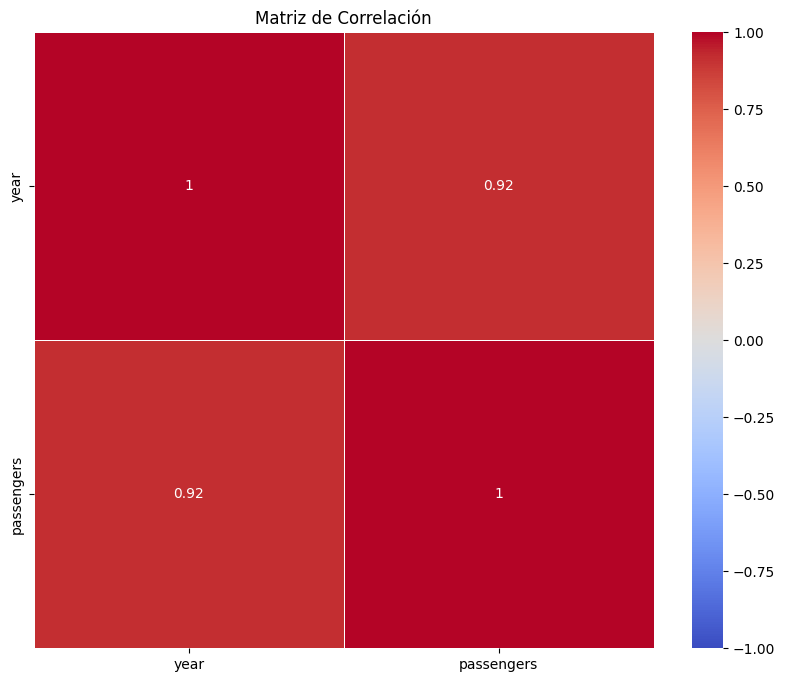

Mean Squared Error: 627.0574784251519
R^2 Score: 0.9368985513011854


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# cargar el dataset de vuelos
data = sns.load_dataset('flights')  
# muestra las primeras filas del dataset
print(data.head())
# validar los tipos de datos y la información general del dataset
print(data.describe())
print(data.shape)

#matriz de correlación
corr_matriz = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz, annot=True, cmap='coolwarm', linewidths=0.5, vmax=1, vmin=-1)
plt.title('Matriz de Correlación')
plt.show()

# Seleccionar las características y la variable objetivo
X = data.drop(columns=['passengers'])  # Reemplaza 'passengers' con el nombre de tu variable objetivo
y = data['passengers']  # Reemplaza 'passengers' con el nombre de tu variable objetivo
# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Crear el modelo de regresión lineal
model = LinearRegression()
# Entrenar el modelo
X_train_encoded = pd.get_dummies(X_train, columns=['month'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['month'], drop_first=True)
model.fit(X_train_encoded, y_train)
# Hacer predicciones
y_pred = model.predict(X_test_encoded)
# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')



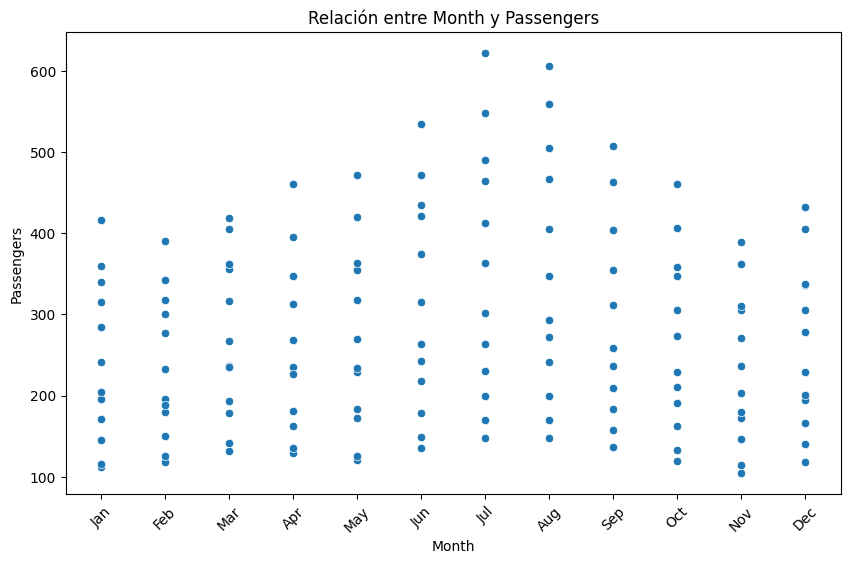

In [7]:
x=data['month']  # Reemplaza 'month' con el nombre de tu variable independiente
y=data['passengers']  # Reemplaza 'passengers' con el nombre de tu variable dependiente
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y)
plt.title('Relación entre Month y Passengers')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.xticks(rotation=45)
plt.show()


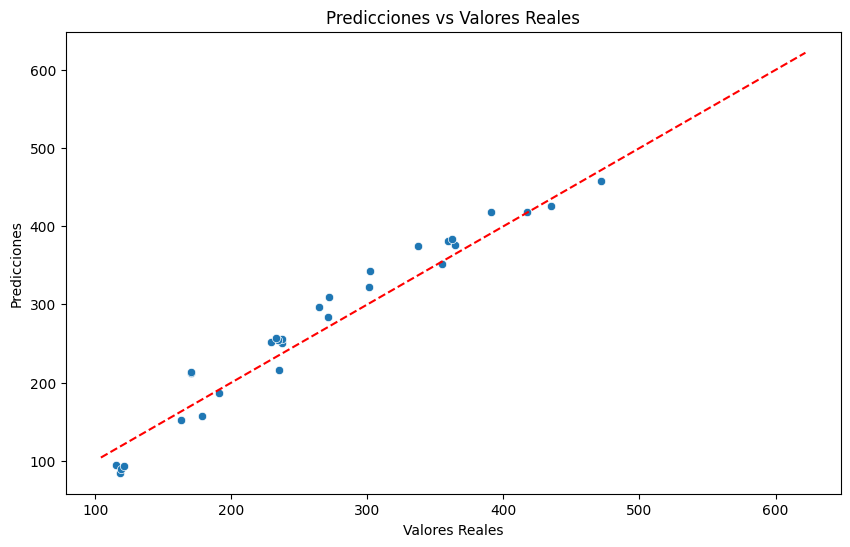

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Línea de referencia para una predicción perfecta
plt.show()  